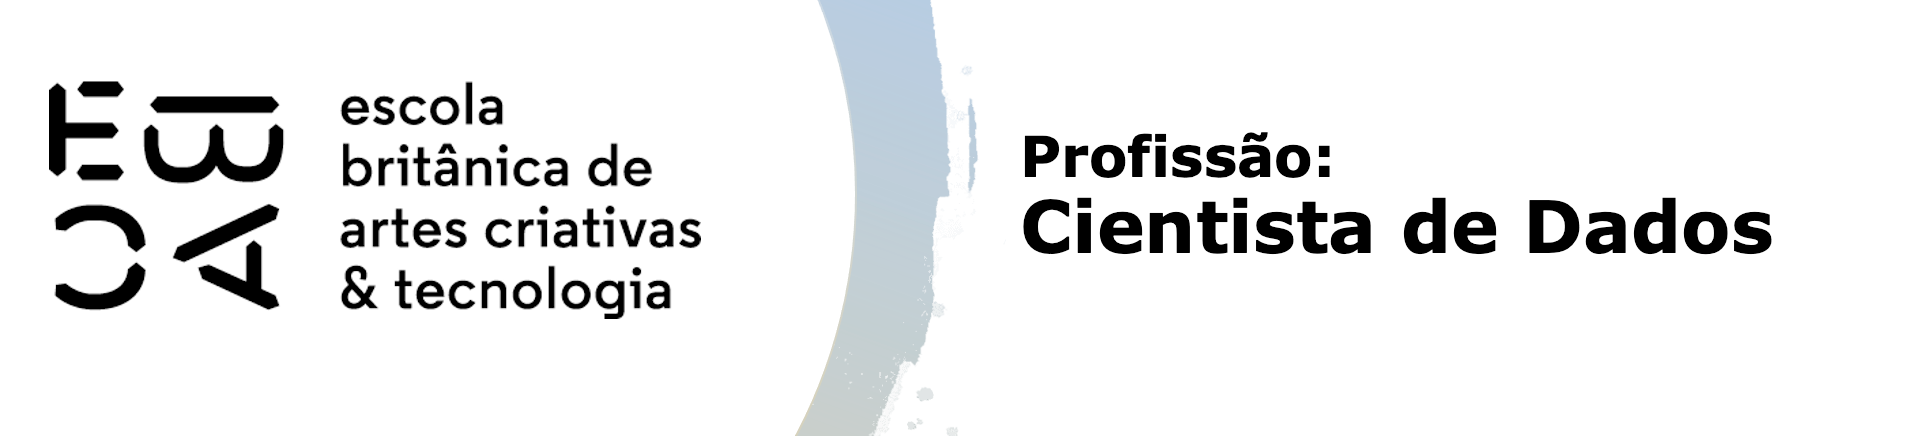

# Tarefa

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo é tentar agrupar os clientes conforme seu comportamento de navegação entre páginas administrativas, informativas e de produtos. 

As variáveis estão descritas abaixo (em tradução livre do link indicado).

Por este motivo, o escopo desta análise estará fechado nas primeiras seis variáveis da tabela, referentes a quantidade e tempo de acesso por tipo de página, atributos que falam mais do comportamento de navegação do cliente que de características da página o da época do ano.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv('Profissão Cientista de Dados M29 - online_shoppers_intention.csv')

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [7]:
variaveis_escopo = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration'
]

In [8]:
df[variaveis_escopo].isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
dtype: int64

In [9]:
df[variaveis_escopo].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230


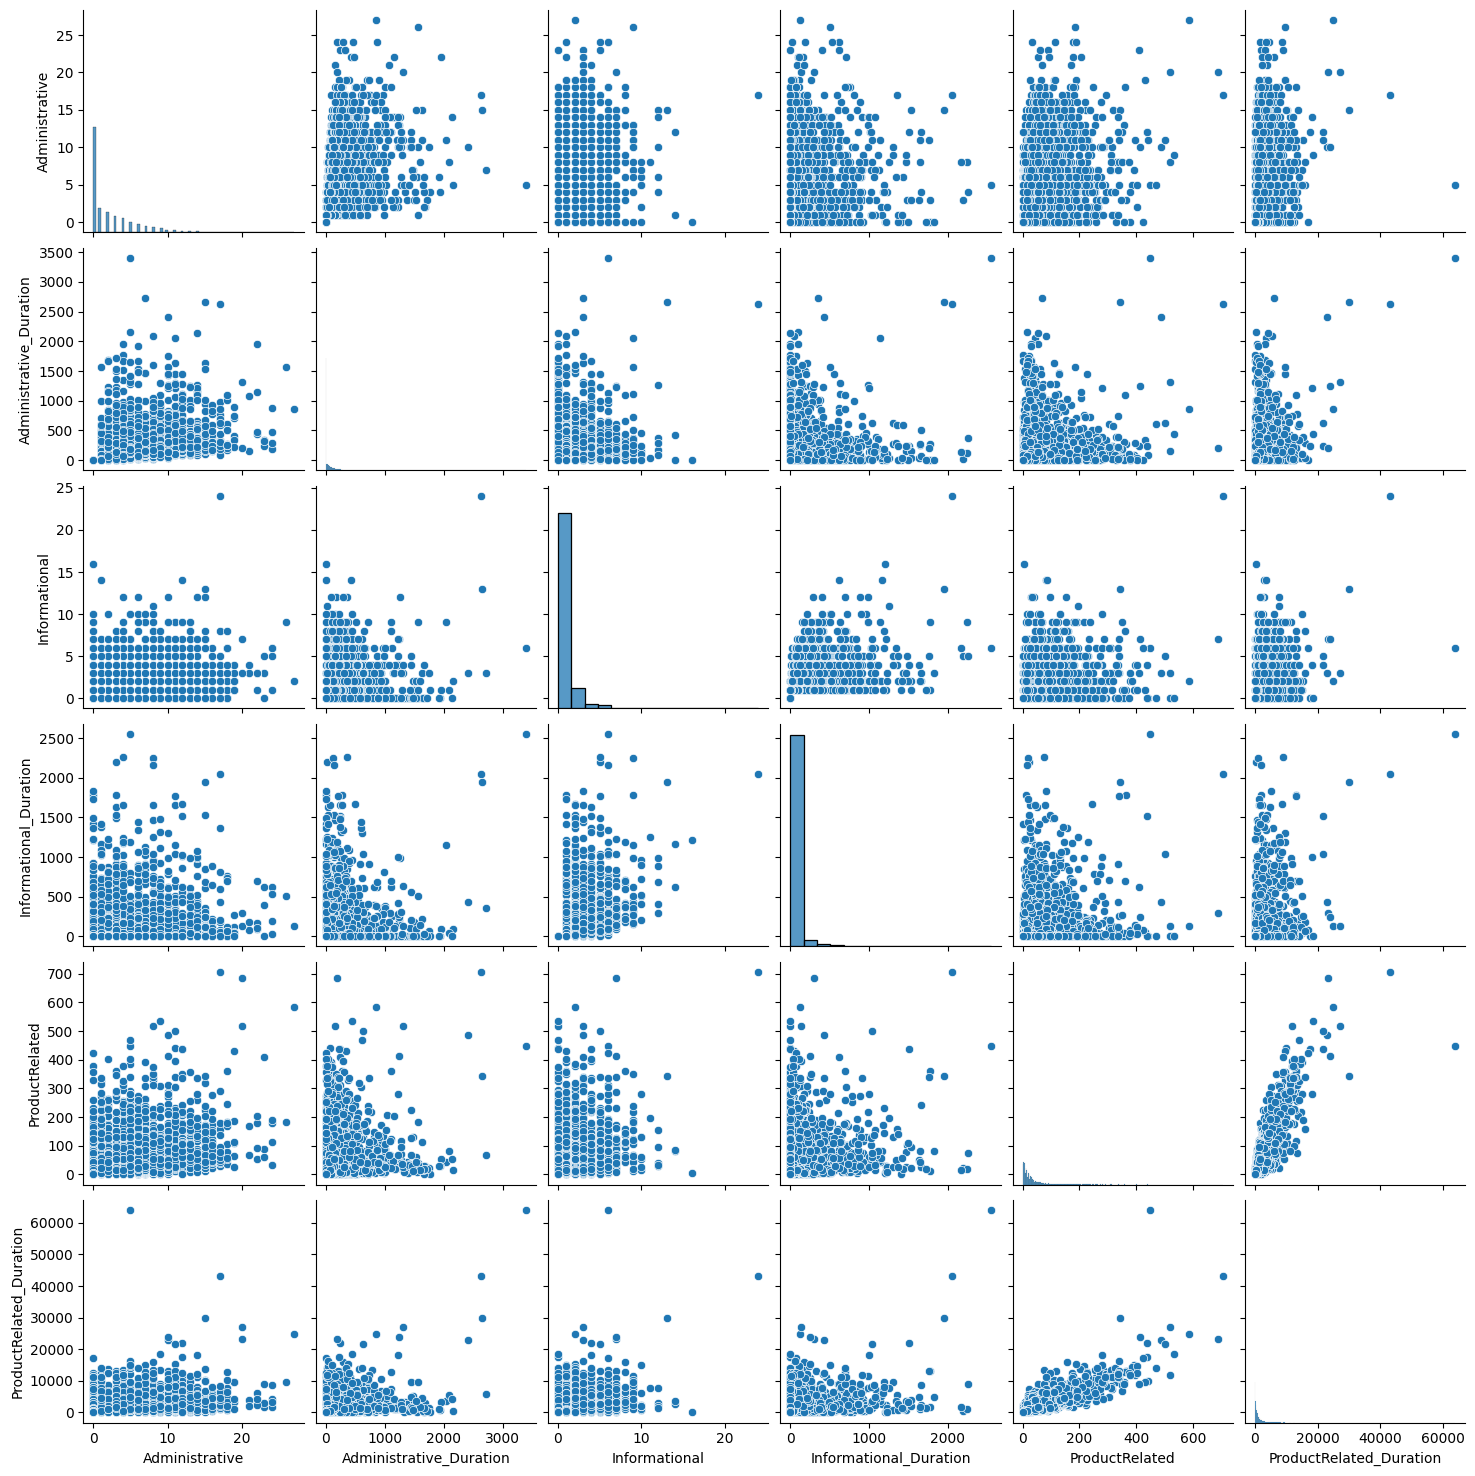

In [10]:
sns.pairplot(df[variaveis_escopo])
plt.show()

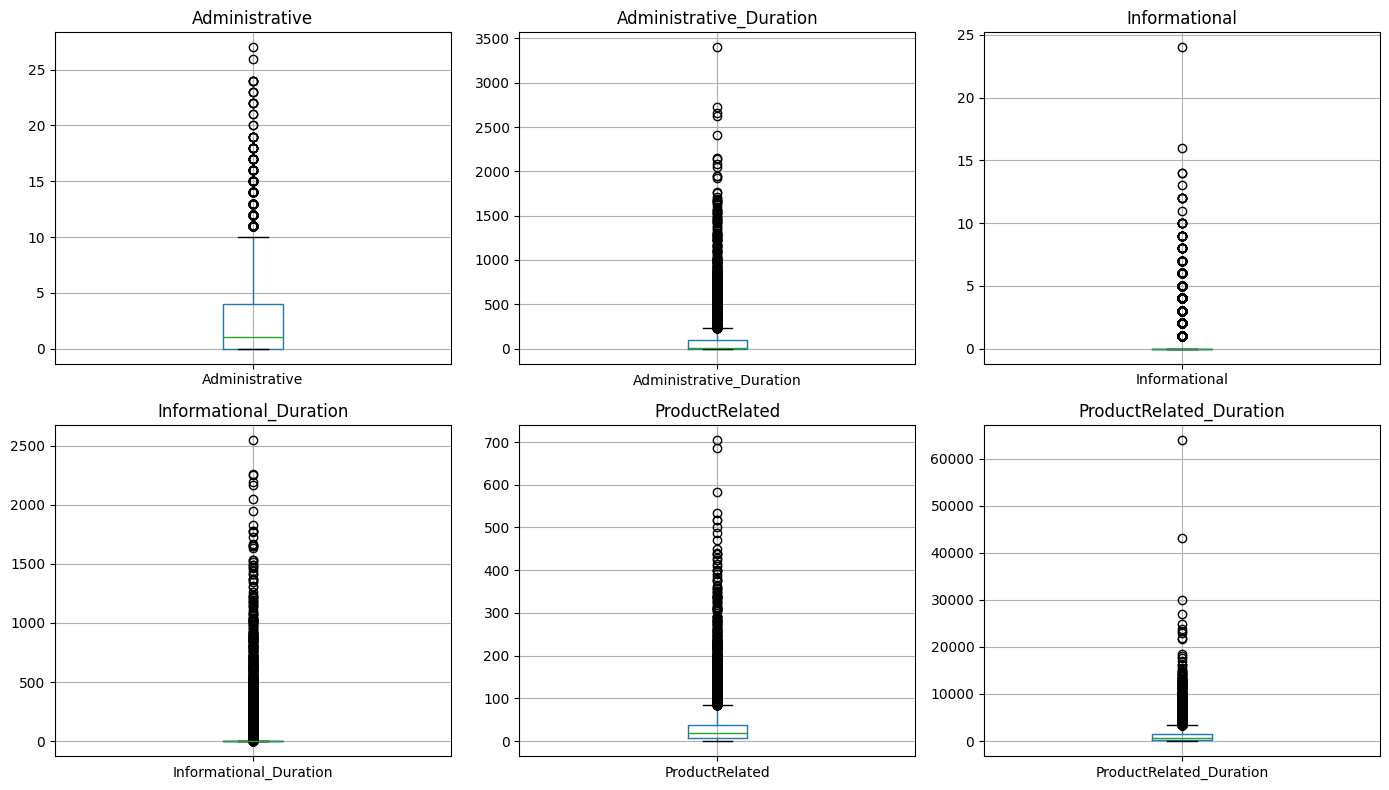

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variaveis_escopo):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Número de grupos

Utilize as técnicas vistas em aula que te ajudem a decidir pelo número de grupos a ser utilizados.

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [15]:
scaler = StandardScaler()
X_pad = pd.DataFrame(
    scaler.fit_transform(df[variaveis_escopo]),
    columns=variaveis_escopo
)

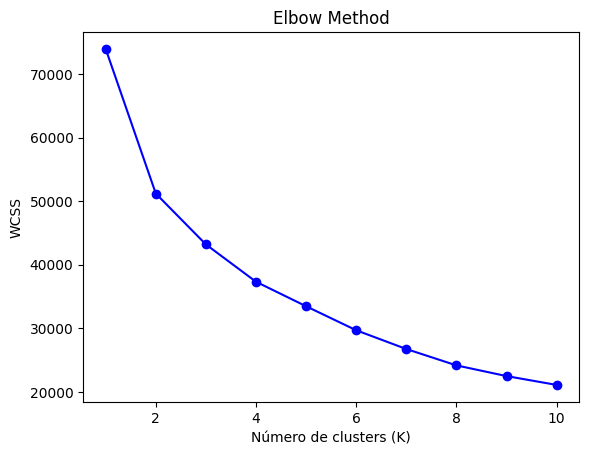

In [16]:
wcss = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pad)
    wcss.append(km.inertia_)

plt.plot(K, wcss, 'bo-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

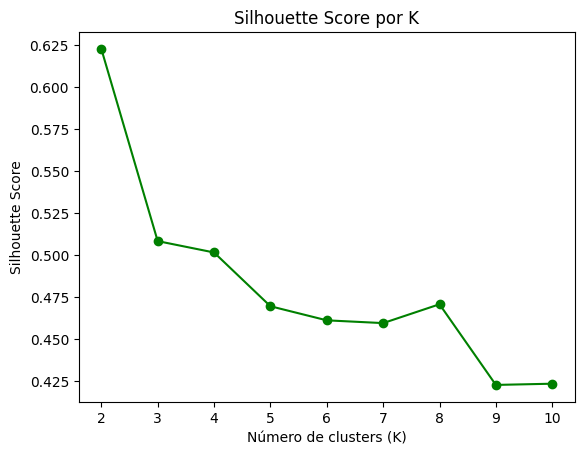

In [17]:
siluetas = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pad)
    siluetas.append(silhouette_score(X_pad, km.labels_))

plt.plot(range(2, 11), siluetas, 'go-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.show()

In [18]:
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['grupo_' + str(k)] = km.fit_predict(X_pad)

O método do cotovelo sugere K=3, onde a queda do WCSS começa a desacelerar, aparentemente. 
O Silhouette Score é máximo em K=2 e cai em K=3. Vou avaliar as duas soluções K=2 e K=3

## Avaliação dos grupos

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

In [19]:
df.groupby('grupo_2')[variaveis_escopo].mean().round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
grupo_2,,,,,,
0,1.50,44.13,0.19,7.09,21.38,776.52
1,7.27,303.07,2.41,200.33,94.46,3728.27


In [20]:
df.groupby('grupo_3')[variaveis_escopo].mean().round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
grupo_3,,,,,,
0,7.03,266.01,4.14,469.45,138.42,5745.80
1,0.93,24.92,0.16,6.57,18.96,690.18
2,6.57,253.31,1.00,43.45,56.67,2103.53


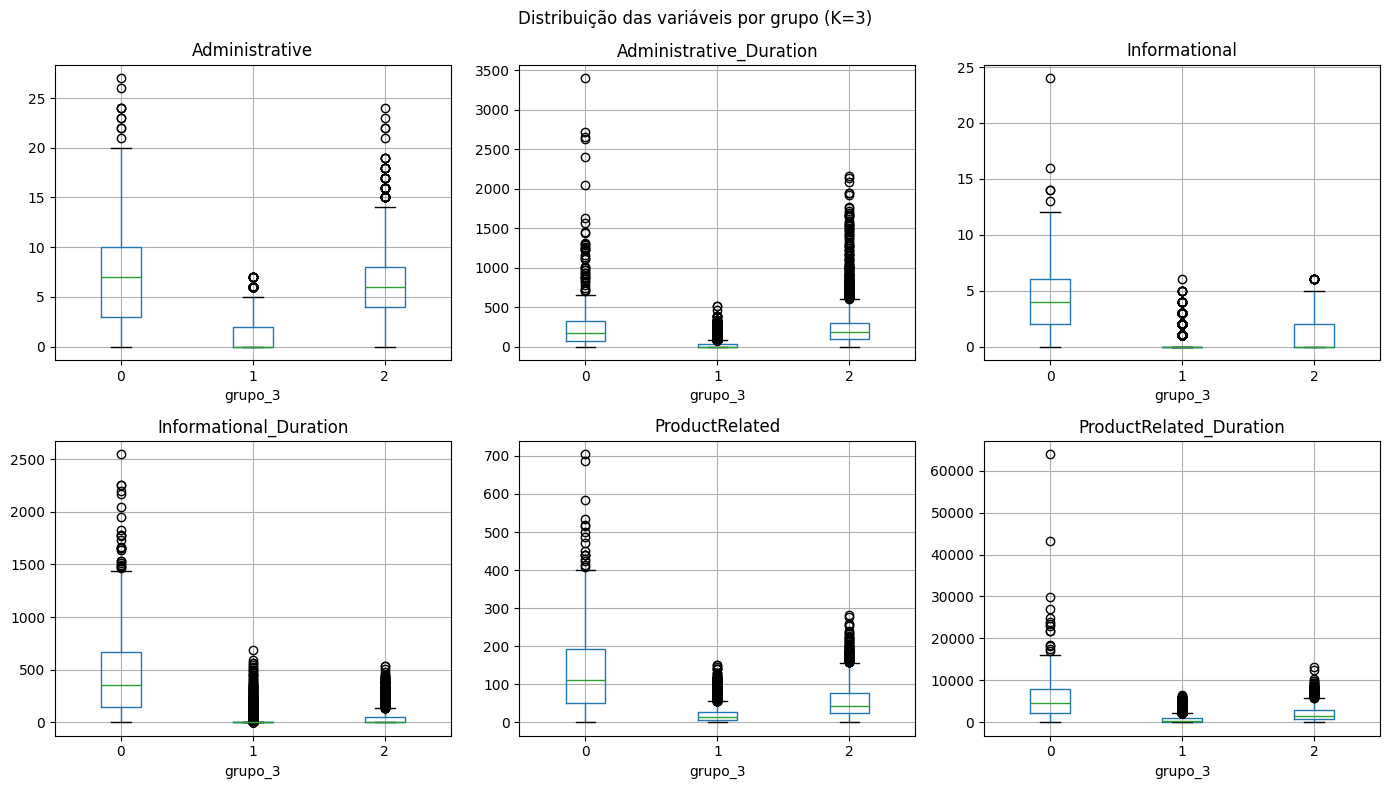

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variaveis_escopo):
    df.boxplot(column=col, by='grupo_3', ax=ax)
    ax.set_title(col)

plt.suptitle('Distribuição das variáveis por grupo (K=3)')
plt.tight_layout()
plt.show()

In [22]:
print('=== Revenue por grupo ===')
print(pd.crosstab(df['grupo_3'], df['Revenue'], normalize='index').round(3))

print('\n=== BounceRates médio por grupo ===')
print(df.groupby('grupo_3')['BounceRates'].mean().round(4))

=== Revenue por grupo ===
Revenue  False  True 
grupo_3              
0        0.694  0.306
1        0.875  0.125
2        0.767  0.233

=== BounceRates médio por grupo ===
grupo_3
0    0.0068
1    0.0272
2    0.0065
Name: BounceRates, dtype: float64


## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?



Cruzando os grupos com variáveis fora do escopo do agrupamento:

- Grupo 0 (Pesquisador) é o mais propenso à compra (30,6% de conversão)
  e tem o menor bounce rate. É o cliente mais valioso.
- Grupo 2 (Focado em produto) tem conversão intermediária (23,3%)
  e bounce baixo. Engajado, mas menos do que o Pesquisador.
- Grupo 1 (Passivo) tem a menor conversão (12,5%) e o maior bounce rate.
  Provável visitante desengajado ou que chegou por acidente.

Conclusão: o comportamento de navegação se mostrou um bom preditor
de propensão a compra. Estrategias de marketing podem ser direcionadas
de forma diferente para cada grupo, especialmente para converter
o Grupo 1, que representa a maior parte dos usuarios.